In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [108]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import matplotlib.patches as patches
from matplotlib.path import Path
from matplotlib.transforms import Bbox
from PIL import Image

In [69]:
# Set the path to the dataset folder
dataset_path = '/Users/alivarastehranjbar/Documents/Python/research_LABs/MER_LAB/ensemble_learning/Datasets/Jacquard/'

# Select the object and scene index
object_name = '1a1ec1cfe633adcdebbf11b1629fc16a'
scene_index = '2_1a1ec1cfe633adcdebbf11b1629fc16a'

In [70]:
# Set the file paths for the different images
grasps_file = dataset_path + object_name + '/{}_grasps.txt'.format(scene_index)
mask_file = dataset_path + object_name + '/{}_mask.png'.format(scene_index)
perfect_depth_file = dataset_path + object_name + '/{}_perfect_depth.tiff'.format(scene_index)
rgb_file = dataset_path + object_name + '/{}_RGB.png'.format(scene_index)
stereo_depth_file = dataset_path + object_name + '/{}_stereo_depth.tiff'.format(scene_index)

# Raw Image plot

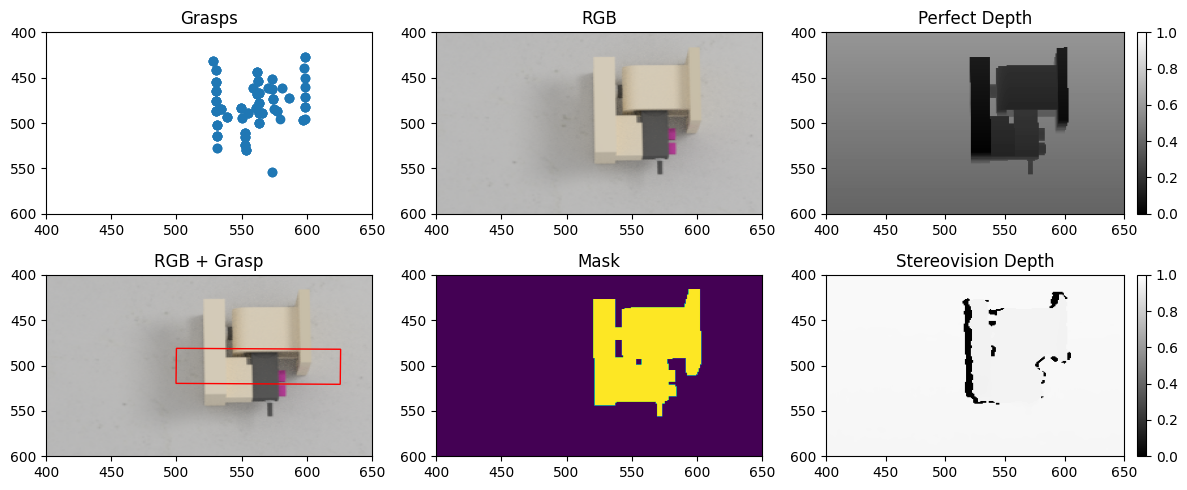

In [72]:
# Zoomed-in region of interest (ROI)
roi_x_min, roi_x_max = 400, 650  # Update the x-axis range as desired
roi_y_min, roi_y_max = 400, 600  # Update the y-axis range as desired
# Load and plot the images
fig, axes = plt.subplots(2, 3, figsize=(12, 5))
#-------------------------------
# Grasps annotations
grasps_data = []
with open(grasps_file, 'r') as file:
    for line in file:
        grasps_data.append([float(value) for value in line.strip().split(';')])
grasps_data = np.array(grasps_data)
axes[0, 0].scatter(grasps_data[:, 0], grasps_data[:, 1])
axes[0, 0].set_title('Grasps')

# RGB image + grasp
rgb_image = Image.open(rgb_file)
axes[1, 0].imshow(rgb_image,aspect="auto")
axes[1, 0].set_title('RGB + Grasp')
x, y, theta, opening, jaw_size = grasps_data[100]
box_width = opening
box_height = jaw_size
rect = patches.Rectangle((x - box_width/2  , y - box_height/2 ), box_width, box_height,angle=theta, linewidth=1, edgecolor='r', facecolor='none')
axes[1, 0].add_patch(rect)
#-------------------------------
# RGB image
# rgb_image = Image.open(rgb_file)
axes[0, 1].imshow(rgb_image,aspect="auto")
axes[0, 1].set_title('RGB')

# Object mask
mask_image = Image.open(mask_file)
axes[1, 1].imshow(mask_image,aspect="auto")
axes[1, 1].set_title('Mask')
#-------------------------------
# Perfect depth image
perfect_depth_image = Image.open(perfect_depth_file)
perfect_depth_array = np.array(perfect_depth_image)
normalized_perfect_depth = (perfect_depth_array - np.min(perfect_depth_array)) / (np.max(perfect_depth_array) - np.min(perfect_depth_array))
im1 = axes[0, 2].imshow(normalized_perfect_depth, cmap='gray',aspect="auto")
axes[0, 2].set_title('Perfect Depth')
fig.colorbar(im1, ax=axes[0, 2], fraction=0.046, pad=0.04)

# Stereovision depth image
stereo_depth_image = Image.open(stereo_depth_file)
stereo_depth_array = np.array(stereo_depth_image)
normalized_stereo_depth = (stereo_depth_array - np.min(stereo_depth_array)) / (np.max(stereo_depth_array) - np.min(stereo_depth_array))
im2 = axes[1, 2].imshow(normalized_stereo_depth, cmap='gray',aspect="auto")
axes[1, 2].set_title('Stereovision Depth')
fig.colorbar(im2, ax=axes[1, 2], fraction=0.046, pad=0.04)
#-------------------------------
# setting same lim:
for i in range(0,2):
    for j in range(0,3):
        axes[i, j].set_xlim(roi_x_min, roi_x_max)
        axes[i, j].set_ylim(roi_y_max, roi_y_min)

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()


# Model Output plot

## Pre-Trained models location

- GG-CNN
    - Cornell
        - color: ./ensemble_learning/Experts/Generative/pretrained_weights/cornell/color/epoch_37_iou_0.80
        - depth: ./ensemble_learning/Experts/Generative/pretrained_weights/cornell/depth/ggcnn_epoch_23_cornell
    - Jacquard
        - color: ./ensemble_learning/Experts/Generative/pretrained_weights/jacquard/color/epoch_41_iou_0.82
        - depth: ./ensemble_learning/Experts/Generative/pretrained_weights/jacquard/depth/epoch_34_iou_0.89

- GPNN
    - None


- GR-CNN
    - Cornell
        - ch16: ./ensemble_learning/Experts/Residual/trained-models/cornell-randsplit-rgbd-grconvnet3-drop1-ch16
        - ch32: ./ensemble_learning/Experts/Residual/trained-models/cornell-randsplit-rgbd-grconvnet3-drop1-ch32
    - Jacquard
        - depth-ch32: ./ensemble_learning/Experts/Residual/trained-models/jacquard-d-grconvnet3-drop0-ch32
        - RGB-D-ch32: ./ensemble_learning/Experts/Residual/trained-models/jacquard-rgbd-grconvnet3-drop0-ch32

./Experts/Residual/env/bin/python3 ./Experts/Residual/evaluate_img_cu.py --network /Users/alivarastehranjbar/Documents/Python/research_LABs/MER_LAB/ensemble_learning/Experts/Residual/trained-models/jacquard-rgbd-grconvnet3-drop0-ch32/epoch_48_iou_0.93 --dataset jacquard --dataset-path /Users/alivarastehranjbar/Documents/Python/research_LABs/MER_LAB/ensemble_learning/Datasets/Jacquard --iou-eval --input-size 300

In [295]:
path = '/Users/alivarastehranjbar/Documents/Python/research_LABs/MER_LAB/ensemble_learning/Datasets/Jacquard'
a = np.load(path + '/0_a.npy')
q = np.load(path +'/0_q.npy')
w = np.load(path +'/0_w.npy')
img_RGB = np.load(path +'/0_RGB.npy')
img_D = np.load(path +'/0_Depth.npy')

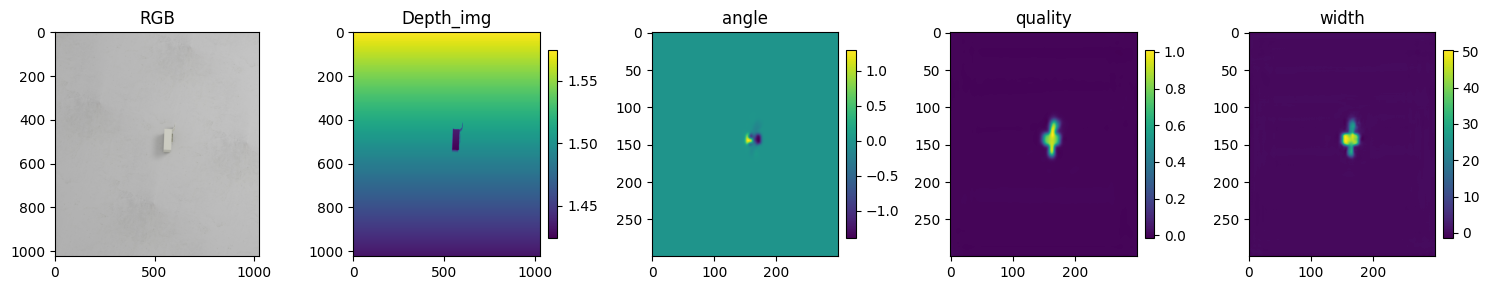

In [300]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

axes[0].imshow(img_RGB,aspect="auto")
axes[0].set_title('RGB')

im1 = axes[1].imshow(img_D,aspect="auto")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
axes[1].set_title('Depth_img')

im2 = axes[2].imshow(a,aspect="auto")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
axes[2].set_title('angle')

im3 = axes[3].imshow(q,aspect="auto")
fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)
axes[3].set_title('quality')

im4 = axes[4].imshow(w,aspect="auto")
fig.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.04)
axes[4].set_title('width')
# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

## Correct

Calculate grasp success using the IoU (Jacquard) metric (e.g. in https://arxiv.org/abs/1301.3592)
    A success is counted if grasp rectangle has a 25% IoU with a ground truth, and is withing 30 degrees.

In [214]:
path = '/Users/alivarastehranjbar/Documents/Python/research_LABs/MER_LAB/ensemble_learning/Datasets/Jacquard/0_test_T_F'
a = np.load(path + '/0_C_a.npy')
q = np.load(path +'/0_C_q.npy')
w = np.load(path +'/0_C_w.npy')
img_RGB = np.load(path +'/0_C_RGB.npy')
img_D = np.load(path +'/0_C_Depth.npy')
img_g = np.load(path +'/0_C_g.npy')

In [215]:
# Resize the image to the desired dimensions using 'bilinear' interpolation
from skimage.transform import resize
resized_image = resize(img_RGB, img_D.shape, preserve_range=True).astype(img_RGB.dtype)


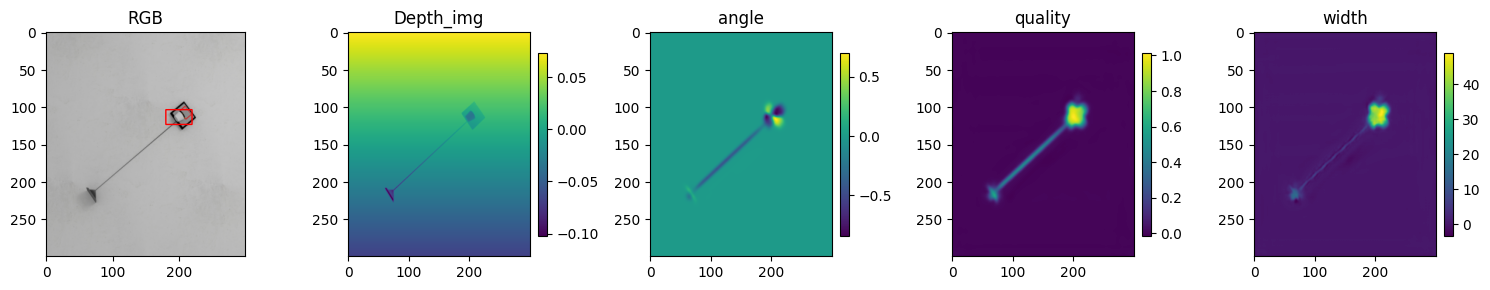

In [216]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

axes[0].imshow(resized_image,aspect="auto")
y, x, theta, opening, jaw_size = img_g
box_width = opening
box_height = jaw_size
rectangle = Polygon(points, closed=True, edgecolor='r', linewidth=2, fill=False)
rect = patches.Rectangle((x - box_width/2  , y - box_height/2 ), box_width, box_height,angle=theta, linewidth=1, edgecolor='r', facecolor='none')
axes[0].add_patch(rect)
# axes[0].add_patch(rectangle)
axes[0].set_title('RGB')

im1 = axes[1].imshow(img_D,aspect="auto")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
axes[1].set_title('Depth_img')

im2 = axes[2].imshow(a,aspect="auto")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
axes[2].set_title('angle')

im3 = axes[3].imshow(q,aspect="auto")
fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)
axes[3].set_title('quality')

im4 = axes[4].imshow(w,aspect="auto")
fig.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.04)
axes[4].set_title('width')
# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

## Failed

In [212]:
path = '/Users/alivarastehranjbar/Documents/Python/research_LABs/MER_LAB/ensemble_learning/Datasets/Jacquard/0_test_T_F'
a = np.load(path + '/83_F_a.npy')
q = np.load(path +'/83_F_q.npy')
w = np.load(path +'/83_F_w.npy')
img_RGB = np.load(path +'/83_F_RGB.npy')
img_D = np.load(path +'/83_F_Depth.npy')
img_g = np.load(path +'/83_F_g.npy')

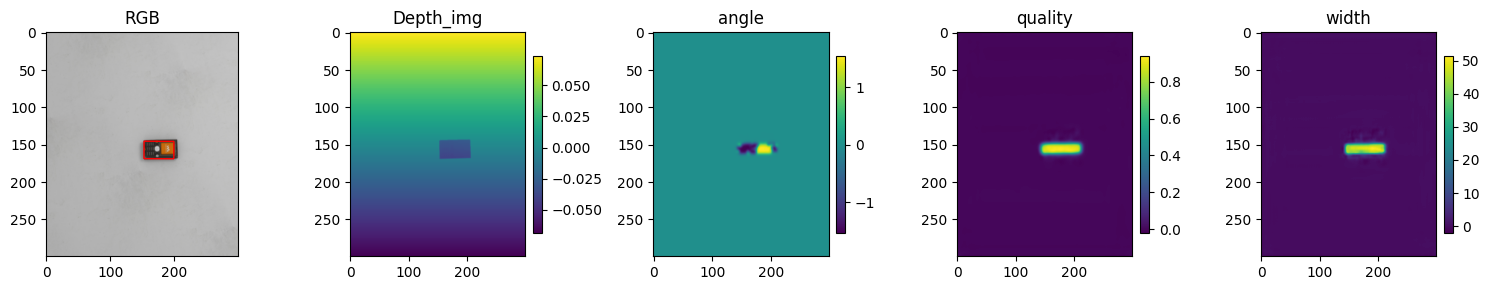

In [213]:
resized_image = resize(img_RGB, img_D.shape, preserve_range=True).astype(img_RGB.dtype)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

axes[0].imshow(resized_image,aspect="auto")
y, x, theta, opening, jaw_size = img_g
box_width = opening
box_height = jaw_size
rectangle = Polygon(points, closed=True, edgecolor='r', linewidth=2, fill=False)
rect = patches.Rectangle((x - box_width/2  , y - box_height/2 ), box_width, box_height,angle=theta, linewidth=1, edgecolor='r', facecolor='none')
axes[0].add_patch(rect)
axes[0].set_title('RGB')

im1 = axes[1].imshow(img_D,aspect="auto")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
axes[1].set_title('Depth_img')

im2 = axes[2].imshow(a,aspect="auto")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
axes[2].set_title('angle')

im3 = axes[3].imshow(q,aspect="auto")
fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)
axes[3].set_title('quality')

im4 = axes[4].imshow(w,aspect="auto")
fig.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.04)
axes[4].set_title('width')
# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

# Grasp DataFrame

In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

# Load the data from a CSV file or DataFrame
data = pd.read_csv(grasps_file, sep=';',names=["Sequence", "Start", "End", "Coverage"])

# Data Exploration
print(data.head())  # Show the first few rows of the data
print(data.describe())  # Summary statistics



       534.0  484.13666     90.0  171.41  26.5407
0  534.00000  484.13666  90.0000  171.41  13.2703
1  534.00000  484.13666  90.0000  171.41  39.8110
2  534.00000  484.13666  90.0000  171.41  53.0814
3  534.00000  484.13666  90.0000  171.41  79.6220
4  574.00082  473.22140  -0.4228   90.00  25.7924
            534.0   484.13666        90.0      171.41     26.5407
count  179.000000  179.000000  179.000000  179.000000  179.000000
mean   559.061148  480.390471   16.263556   79.836884   39.536931
std     21.716312   25.893492   32.621465   50.027046   21.735120
min    528.071530  426.674110  -12.218700    9.000000   12.504400
25%    538.546490  462.647010   -0.397700   28.500000   25.765650
50%    561.646230  483.221760    0.396400   88.500000   38.688700
75%    573.000710  494.880935   15.287900  123.000000   51.900050
max    599.000110  553.735250   90.000000  171.410000   79.622000


In [123]:
data.head()

,534.0,484.13666,90.0,171.41,26.5407
0,534.00000,484.13666,90.0000,171.41,13.2703
1,534.00000,484.13666,90.0000,171.41,39.8110
2,534.00000,484.13666,90.0000,171.41,53.0814
3,534.00000,484.13666,90.0000,171.41,79.6220
4,574.00082,473.22140,-0.4228,90.00,25.7924


In [118]:
# Data Visualization
sns.histplot(data['grasp'], kde=True)  # Plot a histogram with KDE
plt.xlabel('Grasp')
plt.ylabel('Frequency')
plt.title('Robot Grasp Distribution')
plt.show()

KeyError: 'grasp'

In [115]:


sns.boxplot(data['grasp'])
plt.ylabel('Grasp')
plt.title('Robot Grasp Distribution')
plt.show()

sns.violinplot(data['grasp'])
plt.ylabel('Grasp')
plt.title('Robot Grasp Distribution')
plt.show()

# Statistical Tests
_, p_value = shapiro(data['grasp'])  # Shapiro-Wilk normality test
print('p-value:', p_value)

       534.0;484.13666;90.0;171.41;26.5407
0      534.0;484.13666;90.0;171.41;13.2703
1       534.0;484.13666;90.0;171.41;39.811
2      534.0;484.13666;90.0;171.41;53.0814
3       534.0;484.13666;90.0;171.41;79.622
4  574.00082;473.2214;-0.4228;90.0;25.7924
        534.0;484.13666;90.0;171.41;26.5407
count                                   179
unique                                  179
top     534.0;484.13666;90.0;171.41;13.2703
freq                                      1


KeyError: 'grasp'

In [51]:
x, y, theta, opening, jaw_size = grasps_data[20]

In [52]:
grasps_data[20]

array([605.00307, 489.20609, -68.0647 , 136.5    ,  78.6342 ])

In [66]:
grasps_data[10]

array([574.13861, 474.72162, -67.9944 , 135.     ,  13.0981 ])

In [64]:
grasps_data[1]

array([583.90408, 479.20119, -66.2885 , 135.     ,  13.0927 ])